# 静磁场灵敏度测量

测量静磁场的色散线形，根据色散斜率和功率谱密度计算磁场灵敏度。

## 硬件连接说明
- **Pump 调制**: DG4000 (DG4E222800868) CH1 输出 100MHz 正弦波 → RF 开关 IN
- **RF 开关门控**: DG4000 (DG4E222800868) CH2 输出脉冲方波 → RF 开关 CTRL
- **RF 开关输出**: RF 开关 OUT → AOM（Pump 光调制）
- **10Hz 时序信号**: DG4000 (DG4E242401288) CH2 输出（由 DG4000_Z_field 的 CH2 提供）
- **SYNC 触发**: DG4000 (DG4E242401288) CH1 SYNC → HF2 辅助输入

## 注意事项
- 数据采集前需关闭 Temp_Switch (0V)，避免温控磁场干扰锁相读数
- 采集结束后立即打开温控，等待温度稳定
- RF 开关输出端需串 0.1μF 隔直电容再接 AOM

In [1]:
from pathlib import Path
import sys
# 自动定位项目根目录
project_root = Path.cwd()
while not (project_root / "params").exists() and project_root.parent != project_root:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import yaml
import time
import json
from datetime import datetime
import matplotlib.pyplot as plt

# 设备库
from gs200 import GS200Instrument
from signal_generator import DG4000Instrument
from tec_controller import TECInstrument
from lockin_amplifier import (
    HF2Instrument, DAQConfig, DAQResult,
    SignalInputConfig, OscillatorConfig, DemodulatorConfig,
    demod, daq,
)

print("所有库导入成功")

所有库导入成功


In [2]:
# 加载物理量→仪器映射
with open(project_root / "params" / "mapping.yaml", encoding="utf-8") as f:
    MAPPING = yaml.safe_load(f)["mapping"]

# 加载安全限值
with open(project_root / "params" / "safety_limits.yaml", encoding="utf-8") as f:
    LIMITS = yaml.safe_load(f)["safety_limits"]

# ========== 实验参数 ==========
EXPERIMENT_TYPE = "Static_Magnetic_Field_Sensitivity"
PURPOSE = "dispersion_and_sensitivity"

SCAN_VARIABLE = "Z_magnetic_field"
RAMP_LOW = -0.5
RAMP_HIGH = 0.5
RAMP_FREQ = 1.0
RAMP_SYMMETRY = 20
DAQ_DURATION = 1

FIXED_PARAMS = {
    "Pump_laser_power": 0.2,         "Probe_laser_power": 0.2,
    "temperature": 100,              "Temp_Switch": 5.0,
    "Time_sequence": 10.0,           "main_magnetic_field": 9.305,
    "X_magnetic_field": 0,         "Y_magnetic_field": 0,
    "Time_sequence_2": 0.0,
}

PUMP_MOD_FREQ = 90e3                # Pump 调制重复频率 (Hz)
PUMP_MOD_AMPLITUDE = 0.18           # 100MHz 载波幅度 (Vpp)
PUMP_MOD_DUTY = 5                   # 脉冲占空比 (%), 与任意波方案一致

# RF 开关控制信号参数
RF_GATE_AMPLITUDE = 5.0             # CH2 门控脉冲幅度 (Vpp), 适配 TTL
RF_GATE_OFFSET = 2.5                # CH2 门控脉冲偏置 (V), 0~5V TTL
RF_GATE_DELAY = 0.0                 # CH2 门控脉冲延迟 (s)

# ========== HF2 配置 ==========
HF2_DEMOD_IDX = 0
HF2_OSC_FREQ = 90e3
HF2_DEMOD_ORDER = 4
HF2_SIGNAL_RANGE = 2.0
HF2_DEMOD_RATE = 1000
HF2_DEMOD_TC = 0.001
HF2_NOISE_RATE = 50000
HF2_NOISE_TC = 1e-6

# ========== 噪声采集参数 ==========
NOISE_N_AVG = 10            # 噪声采集次数，增大可降低频谱涨落
NOISE_DURATION = 1.0        # 每次采集时长 (s)

# ========== 磁场校准 ==========
Z_V_TO_NT = 3517
Z_V_TO_FT = Z_V_TO_NT * 1000000

# ========== DAQ 触发 ==========
DAQ_TRIGGER_CHANNEL = 0
DAQ_TRIGGER_LEVEL = 1
DAQ_TRIGGER_SLOPE = 0

# ========== 运行目录命名 ==========
# 格式: MMDD_HHMM_短标签，如 "0517_1120_sens"
# 在此处修改短标签即可自定义目录名
RUN_TAG = "sens"

print("配置已加载")

配置已加载


In [3]:
# 安全边界检查函数
def validate_safety_limit(name, value):
    """检查数值是否在安全范围内，超出则报错."""
    lim = LIMITS.get(name)
    if lim is None:
        return value
    lo, hi = lim["min"], lim["max"]
    if lo is not None and hi is not None:
        if value < lo or value > hi:
            raise ValueError(
                f"[安全拦截] {name}={value} 超出范围 [{lo}, {hi}]"
            )
    return value


devices = {}

try:
    # ---- GS200: 主磁场 ----
    gs_cfg = MAPPING["main_magnetic_field"]
    gs = GS200Instrument(gs_cfg["resource"])
    gs.connect()
    print(f"GS200 已连接: {gs.idn()}")
    gs.set_source_function(gs_cfg["source_function"])
    # safety_limits.yaml 存储单位: mA, set_current_limit 单位: A
    gs.set_current_limit(LIMITS["main_magnetic_field"]["max"] / 1000.0)
    devices["gs200"] = gs

    # ---- DG4000: Z 磁场扫描 (共 2 通道) ----
    dg_sweep_cfg = MAPPING["Z_magnetic_field"]
    dg_sweep = DG4000Instrument(dg_sweep_cfg["resource"], channel=1)
    dg_sweep.connect()
    print(f"Z 场 DG4000 已连接: {dg_sweep.idn()}")
    dg_sweep.set_ref_clock_source("EXTernal")
    print(f"  -> 时钟源: 外部")
    devices["dg_sweep"] = dg_sweep

    # ---- DG4000: Pump/Probe 光功率 ----
    dg_laser_cfg = MAPPING["Pump_laser_power"]
    dg_laser = DG4000Instrument(dg_laser_cfg["resource"], channel=1)
    dg_laser.connect()
    print(f"光功率 DG4000 已连接: {dg_laser.idn()}")
    devices["dg_laser"] = dg_laser

    # ---- DG4000: X/Y 补偿磁场 ----
    dg_comp_cfg = MAPPING["X_magnetic_field"]
    dg_comp = DG4000Instrument(dg_comp_cfg["resource"], channel=1)
    dg_comp.connect()
    print(f"补偿场 DG4000 已连接: {dg_comp.idn()}")
    dg_comp.set_ref_clock_source("EXTernal")
    print(f"  -> 时钟源: 外部")
    devices["dg_comp"] = dg_comp

    # ---- DG4000: Pump 调制 + 时序 ----
    dg_mod_cfg = MAPPING["Pump_modulation"]
    dg_mod = DG4000Instrument(dg_mod_cfg["resource"], channel=1)
    dg_mod.connect()
    print(f"调制 DG4000 已连接: {dg_mod.idn()}")
    devices["dg_mod"] = dg_mod

    # ---- DG4000: 温度开关 ----
    dg_temp_cfg = MAPPING["Temp_Switch"]
    dg_temp = DG4000Instrument(dg_temp_cfg["resource"], channel=2)
    dg_temp.connect()
    print(f"温控 DG4000 已连接: {dg_temp.idn()}")
    devices["dg_temp"] = dg_temp

    # ---- TEC103: 温度控制器 ----
    tec_cfg = MAPPING["temperature"]
    tec = TECInstrument(port=tec_cfg["resource"])
    tec.connect()
    print(f"TEC103 已连接")
    devices["tec"] = tec

    # ---- HF2: 锁相放大器 ----
    hf2_cfg = MAPPING["lockin_r"]
    hfi = HF2Instrument(
        host=hf2_cfg.get("host", "127.0.0.1"),
        port=hf2_cfg.get("port", 8005),
        api_level=1,
        device_id=hf2_cfg["device_id"],
    )
    hfi.connect()
    print(f"HF2 已连接: {hfi.idn}")
    hfi.set_extclk(True)
    print(f"  -> HF2 时钟源: 外部")
    devices["hf2"] = hfi

except Exception as e:
    print(f"设备连接失败: {e}")
    raise

print(f"\n所有设备连接完成，共 {len(devices)} 个设备")

GS200 已连接: YOKOGAWA,GS210,90Z631552,2.02
Z 场 DG4000 已连接: Rigol Technologies,DG4162,DG4E242401288,00.01.14
  -> 时钟源: 外部
光功率 DG4000 已连接: Rigol Technologies,DG4162,DG4E231500376,00.01.14
补偿场 DG4000 已连接: Rigol Technologies,DG4162,DG4E234902522,00.01.14
  -> 时钟源: 外部
调制 DG4000 已连接: Rigol Technologies,DG4162,DG4E222800868,00.01.14
温控 DG4000 已连接: RIGOL TECHNOLOGIES,DG912 Pro,DG9Q271200104,00.02.00.00.05
TEC103 已连接
HF2 已连接: HF2LI
  -> HF2 时钟源: 外部

所有设备连接完成，共 8 个设备


In [4]:
hfi = devices["hf2"]
tec = devices["tec"]
gs = devices["gs200"]
dg_laser = devices["dg_laser"]
dg_comp = devices["dg_comp"]
dg_sweep = devices["dg_sweep"]
dg_mod = devices["dg_mod"]
dg_temp = devices["dg_temp"]

# ---- 设置固定参数 ----

# 1. Pump 光功率 (DC 电平)
validate_safety_limit("Pump_laser_power", FIXED_PARAMS["Pump_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Pump_laser_power"], channel=1)
print(f"Pump 光功率: {FIXED_PARAMS['Pump_laser_power']} V DC")

# 2. Probe 光功率 (DC 电平)
validate_safety_limit("Probe_laser_power", FIXED_PARAMS["Probe_laser_power"])
dg_laser.setup_dc(FIXED_PARAMS["Probe_laser_power"], channel=2)
print(f"Probe 光功率: {FIXED_PARAMS['Probe_laser_power']} V DC")

# 3. X/Y 补偿磁场 — 非零时自动打开输出，0 时关闭
validate_safety_limit("X_magnetic_field", FIXED_PARAMS["X_magnetic_field"])
validate_safety_limit("Y_magnetic_field", FIXED_PARAMS["Y_magnetic_field"])
dg_comp.setup_dc(FIXED_PARAMS["X_magnetic_field"], channel=1)
dg_comp.setup_dc(FIXED_PARAMS["Y_magnetic_field"], channel=2)
x_on = abs(FIXED_PARAMS["X_magnetic_field"]) > 0
y_on = abs(FIXED_PARAMS["Y_magnetic_field"]) > 0
dg_comp.set_output(x_on, channel=1)
dg_comp.set_output(y_on, channel=2)
x_label = f"{FIXED_PARAMS['X_magnetic_field']} V {'(ON)' if x_on else '(OFF)'}"
y_label = f"{FIXED_PARAMS['Y_magnetic_field']} V {'(ON)' if y_on else '(OFF)'}"
print(f"X 补偿磁场: {x_label}")
print(f"Y 补偿磁场: {y_label}")

# 4. 主磁场 (GS200, 电流模式)
validate_safety_limit("main_magnetic_field", FIXED_PARAMS["main_magnetic_field"])
gs.set_current(FIXED_PARAMS["main_magnetic_field"] / 1000.0)  # mA -> A
gs.set_output(True)
print(f"主磁场: {FIXED_PARAMS['main_magnetic_field']} mA")

# 5. 温度控制
validate_safety_limit("temperature", FIXED_PARAMS["temperature"])
tec.set_target_temperature(FIXED_PARAMS["temperature"], channel=1)
tec.set_enable(True, channel=1)
temp_now = tec.get_temperature(channel=1)
print(f"温度设定: {FIXED_PARAMS['temperature']} °C, 当前: {temp_now:.1f} °C")

# 6. 温度开关 (ON)
validate_safety_limit("Temp_Switch", FIXED_PARAMS["Temp_Switch"])
dg_temp.setup_dc(FIXED_PARAMS["Temp_Switch"], channel=2)
print(f"温度开关: ON ({FIXED_PARAMS['Temp_Switch']} V)")

# 7. 时序信号 (10Hz 方波) → 移到 dg_sweep CH2
validate_safety_limit("Time_sequence", FIXED_PARAMS["Time_sequence"])
dg_sweep.setup_square(freq=10.0, amplitude=FIXED_PARAMS["Time_sequence"],
                      offset=0.0, dcycle=50.0, channel=2)
dg_sweep.set_output(True, channel=2)
print(f"时序信号: 10 Hz 方波, {FIXED_PARAMS['Time_sequence']} V (由 dg_sweep CH2 提供)")

# 8. dg_mod 不再使用 CH2 输出时序, 后续用于 RF 开关门控
#    先预设置 CH2 为脉冲模式 (后面 Pump 调制设置 Cell 中具体配置)

# ---- 创建本次运行目录 (简洁命名: MMDD_HHMM_tag) ----
timestamp = datetime.now().strftime("%m%d_%H%M")
run_dir = project_root / "data" / EXPERIMENT_TYPE / f"{timestamp}_{RUN_TAG}"
run_dir.mkdir(parents=True, exist_ok=True)
(raw_dir := run_dir / "raw").mkdir(exist_ok=True)
(results_dir := run_dir / "results").mkdir(exist_ok=True)
print(f"运行目录: {run_dir}")

print("\n固定参数设置完成")

Pump 光功率: 0.2 V DC
Probe 光功率: 0.2 V DC
X 补偿磁场: 0 V (OFF)
Y 补偿磁场: 0 V (OFF)
主磁场: 9.305 mA
温度设定: 100 °C, 当前: 100.0 °C
温度开关: ON (5.0 V)
时序信号: 10 Hz 方波, 10.0 V (由 dg_sweep CH2 提供)
运行目录: d:\Code\exp_agent\data\Static_Magnetic_Field_Sensitivity\0520_1652_sens

固定参数设置完成


In [5]:
# ---- 配置 RF 开关方案（替代任意波） ----
# 方案说明:
#   dg_mod CH1: 100MHz 连续正弦波 (RF 载波)
#   dg_mod CH2: 脉冲方波 (RF 开关门控, 5% 占空比)
#   RF 开关 OUT → AOM: 只在门控高电平时输出 100MHz
#
# 优点:
#   - 100MHz 是纯净正弦波, 非 DAC 合成, 无采样失真
#   - RF 开关隔离度 >50dB, 无漏光
#   - 各频率下的 100MHz 载波品质一致
# =====================================================

# ---- 1) DG4000 CH1: 100MHz 连续正弦波 ----
print("CH1: 配置 100MHz 连续正弦波...")
dg_mod.setup_sine(freq=100e6, amplitude=PUMP_MOD_AMPLITUDE,
                  offset=0.0, phase=0.0, channel=1)
print(f"  100MHz, 幅度 {PUMP_MOD_AMPLITUDE*1000:.0f} mVpp → RF 开关 IN")

# ---- 2) DG4000 CH2: 脉冲门控信号 ----
#    频率 = PUMP_MOD_FREQ (90 kHz), 脉宽 = duty% × 周期
pulse_width = (PUMP_MOD_DUTY / 100.0) / PUMP_MOD_FREQ
print(f"\nCH2: 配置 {PUMP_MOD_FREQ/1e3:.0f} kHz 脉冲门控...")
print(f"  脉宽: {pulse_width*1e6:.2f} μs ({PUMP_MOD_DUTY}% duty)")
dg_mod.setup_pulse(freq=PUMP_MOD_FREQ, amplitude=RF_GATE_AMPLITUDE,
                   offset=RF_GATE_OFFSET, width=pulse_width, channel=2)
print(f"  {PUMP_MOD_FREQ/1e3:.0f} kHz, {RF_GATE_AMPLITUDE:.1f} Vpp, "
      f"offset {RF_GATE_OFFSET:.1f}V → RF 开关 CTRL")

print("\n✅ RF 开关方案配置完成")
print("  CH1(100MHz) → RF IN | CH2(脉冲) → RF CTRL | RF OUT → AOM")

CH1: 配置 100MHz 连续正弦波...
  100MHz, 幅度 180 mVpp → RF 开关 IN

CH2: 配置 90 kHz 脉冲门控...
  脉宽: 0.56 μs (5% duty)
  90 kHz, 5.0 Vpp, offset 2.5V → RF 开关 CTRL

✅ RF 开关方案配置完成
  CH1(100MHz) → RF IN | CH2(脉冲) → RF CTRL | RF OUT → AOM


In [6]:
# ---- HF2 解调器 0 相位校准 ----
# 校准应在 Pump 光打开、静态磁场条件下进行
# (此时 Z 场输出关闭，不扫场)
# 校准前关闭温控开关，避免温控磁场干扰

# 关闭温控
print("关闭温度开关...")
dg_temp.set_output(False, channel=2)

# 关闭 Z 磁场扫场输出 (DC 0V + 输出关闭)
print("关闭 Z 磁场 (DC 0V, 输出 OFF)...")
dg_sweep.setup_dc(0.0, channel=1)
dg_sweep.set_output(False, channel=1)

# 配置信号输入
sig_in_cfg = SignalInputConfig(
    input_index=0,
    range=HF2_SIGNAL_RANGE,
    ac_coupling=True,
    diff=False,
    impedance=50,
)
demod.configure_signal_input(hfi, sig_in_cfg)
print(f"信号输入已配置: {HF2_SIGNAL_RANGE} V range, AC coupled")

# 配置振荡器 (90 kHz, 匹配 Pump 调制频率)
osc_cfg = OscillatorConfig(
    osc_index=0,
    frequency=HF2_OSC_FREQ,
    source="manual",
)
demod.configure_oscillator(hfi, osc_cfg)
print(f"振荡器已配置: {HF2_OSC_FREQ/1e3:.0f} kHz")

# 配置解调器 0
demod_cfg = DemodulatorConfig(
    demod_index=0,
    enable=True,
    rate=HF2_DEMOD_RATE,
    input_channel=0,
    osc_select=0,
    harmonic=1,
    time_constant=HF2_DEMOD_TC,
    order=HF2_DEMOD_ORDER,
    phase=0.0,
)
actual_rate = demod.configure_demodulator(hfi, demod_cfg)
print(f"解调器 0 已配置: rate={actual_rate:.0f} Sa/s, TC={HF2_DEMOD_TC*1000:.1f} ms")

# 自动相位校准
print("正在进行相位校准...")
calibrated_phase = demod.auto_calibrate_phase(
    hfi, demod_idx=0, tolerance_deg=1.0, max_attempts=5, settle_time=0.2
)
print(f"相位校准完成: {calibrated_phase:.2f}°")

# 验证: 读一组样本查看 X/Y 比值
sample = demod.read_demod_sample(hfi, demod_idx=0)
print(f"校准后样本: R={sample['r']:.6f}, X={sample['x']:.6f}, Y={sample['y']:.6f}")

time.sleep(1)  # 等待系统稳定

# 恢复温控
print("恢复温度开关...")
dg_temp.set_output(True, channel=2)

关闭温度开关...
关闭 Z 磁场 (DC 0V, 输出 OFF)...
信号输入已配置: 2.0 V range, AC coupled
振荡器已配置: 90 kHz
解调器 0 已配置: rate=899 Sa/s, TC=1.0 ms
正在进行相位校准...
相位校准完成: -161.55°
校准后样本: R=1.057974, X=1.057934, Y=0.009194
恢复温度开关...


In [7]:
# ===== 数据采集: Z 场连续扫场 + HF2 DAQ (触发同步) =====
# 硬件连接: DG4000 CH1 [SYNC] → HF2 辅助输入 1 (auxins/0)
# 流程:
#   1. 等待相位校准后的系统稳定 (气室温度、磁场)
#   2. 启动 Z 场 RAMP 扫场
#   3. APPLy 完成后开启 SYNC 输出
#   4. 关闭温控, 等待磁场干扰消退
#   5. HF2 DAQ 触发采集
#   6. 停止扫场, 恢复温控
# =====================================================

print("=" * 50)
print("开始数据采集 (触发同步)")
print("=" * 50)

try:

    # Step 2: 启动 Z 场 RAMP 扫场 (APPLy 会重置 SYNC, 所以先不开)
    print("[2/6] 启动 Z 场斜坡扫场...")
    dg_sweep.setup_ramp(freq=RAMP_FREQ, amplitude=(RAMP_HIGH - RAMP_LOW),
                        offset=0.0, symmetry=RAMP_SYMMETRY, channel=1)

    # Step 3: APPLy 完成后开启 SYNC 输出
    print("[3/6] 开启 Z 场 DG4000 SYNC 输出...")
    dg_sweep.set_sync_state(True, channel=1)
    time.sleep(0.5)

    # Step 4: 关闭温度开关, 等待温控磁场残余消失
    print("[4/6] 关闭温度开关 (等 2 s 消残余磁场)...")
    dg_temp.set_output(False, channel=2)
    time.sleep(1.0)

    # Step 5: HF2 DAQ 触发采集 (等待 SYNC 上升沿启动)
    print(f"[5/6] HF2 DAQ 触发采集 (aux{DAQ_TRIGGER_CHANNEL}, {DAQ_TRIGGER_LEVEL}V)...")
    aux_path = f"/{MAPPING['lockin_r']['device_id']}/auxins/{DAQ_TRIGGER_CHANNEL}/sample.AuxIn{DAQ_TRIGGER_CHANNEL}"
    daq_cfg = DAQConfig(
        device=MAPPING["lockin_r"]["device_id"],
        trigger_type=1,
        trigger_channel=DAQ_TRIGGER_CHANNEL,
        trigger_level=DAQ_TRIGGER_LEVEL,
        trigger_slope=DAQ_TRIGGER_SLOPE,
        trigger_delay=0.0,
        duration=DAQ_DURATION,
        # 使用 actual_rate 而非硬编码常量，确保网格大小与解调器实际速率匹配
        grid_cols=int(actual_rate * DAQ_DURATION),
        grid_rows=1,
        grid_mode=2,
        signal_paths=["sample.r", "sample.x", "sample.y"],
        extra_paths=[aux_path],
    )

    daq_results = daq.acquire_data(
        hfi, config=daq_cfg, demod_idx=0,
        actual_rate=actual_rate, timeout=DAQ_DURATION + 10.0,
    )
    print(f"    DAQ 采集完成, 共 {len(daq_results)} 路信号")

    for result in daq_results:
        print(f"    {result.signal_name}: {len(result.values)} 点")

    # Step 6: 停止扫场, 恢复温控
    print("[6/6] 停止扫场, 恢复温度开关...")
    dg_sweep.set_output(False, channel=1)
    dg_sweep.set_sync_state(False, channel=1)
    dg_temp.set_output(True, channel=2)
    time.sleep(0.5)

    print("=" * 50)
    print("数据采集完成")
    print("=" * 50)

except Exception as e:
    print(f"采集中断: {e}")
    dg_sweep.set_output(False, channel=1)
    dg_sweep.set_sync_state(False, channel=1)
    dg_temp.set_output(True, channel=2)
    raise

开始数据采集 (触发同步)
[2/6] 启动 Z 场斜坡扫场...
[3/6] 开启 Z 场 DG4000 SYNC 输出...
[4/6] 关闭温度开关 (等 2 s 消残余磁场)...
[5/6] HF2 DAQ 触发采集 (aux0, 1V)...
    DAQ 采集完成, 共 4 路信号
    sample.auxin0: 899 点
    sample.r: 899 点
    sample.x: 899 点
    sample.y: 899 点
[6/6] 停止扫场, 恢复温度开关...
数据采集完成


In [8]:
# ---- 解析 DAQ 结果 ----
# 触发时刻 (t=0) = ramp 周期起点 (V=RAMP_LOW)
# 对称性 20%: 前 20% 上升 (-0.5V→+0.5V), 后 80% 下降 (+0.5V→-0.5V)
# 有效数据窗口: t_norm 在 10%~90% (参考已有代码 start_pos/end_pos)

T_ramp = 1.0 / RAMP_FREQ

recorded_data = {}
aux_key = None

for result in daq_results:
    if "auxin" in result.signal_name.lower():
        aux_key = f"aux_{result.signal_name}"
        recorded_data[aux_key] = result.values
        recorded_data[f"{aux_key}_time"] = result.time
    else:
        recorded_data[result.signal_name] = result.values
        recorded_data[f"{result.signal_name}_time"] = result.time

if len(daq_results) > 0:
    t = daq_results[0].time
    s = RAMP_SYMMETRY / 100.0
    t_norm = t / T_ramp  # t=0 = 周期起点 = SYNC 触发

    if s >= 1.0:
        V_z = RAMP_LOW + (RAMP_HIGH - RAMP_LOW) * t_norm
    elif s <= 0.0:
        V_z = RAMP_HIGH - (RAMP_HIGH - RAMP_LOW) * t_norm
    else:
        rising = t_norm % 1.0 < s
        tn = t_norm % 1.0
        V_z = np.where(rising,
            RAMP_LOW + (RAMP_HIGH - RAMP_LOW) * tn / s,
            RAMP_HIGH - (RAMP_HIGH - RAMP_LOW) * (tn - s) / (1.0 - s))

    recorded_data["Z_voltage"] = V_z
    recorded_data["t_norm"] = t_norm % 1.0
    recorded_data["rising_mask"] = (t_norm % 1.0) < s
    # 有效数据窗口: 前 10%~后 10% 裁剪 (参考已有分析代码)
    recorded_data["effective_mask"] = ((t_norm % 1.0) > 0.1) & ((t_norm % 1.0) < 0.9)

np.savez(raw_dir / "scan_data.npz", **recorded_data)
try:
    import pandas as pd
    pd.DataFrame(recorded_data).to_csv(raw_dir / "scan_log.csv", index=False)
except ImportError:
    pass

snapshot = {
    "experiment_type": EXPERIMENT_TYPE, "purpose": PURPOSE,
    "timestamp": timestamp, "z_v_to_nt": Z_V_TO_NT,
    "ramp_low": RAMP_LOW, "ramp_high": RAMP_HIGH,
    "daq_duration": DAQ_DURATION,
    "hf2_demod_tc": HF2_DEMOD_TC, "hf2_demod_rate": HF2_DEMOD_RATE,
    "pump_mod_freq": PUMP_MOD_FREQ,
    "pump_mod_amplitude": PUMP_MOD_AMPLITUDE,
    "pump_mod_duty": PUMP_MOD_DUTY,
}
with open(run_dir / "params.yaml", "w", encoding="utf-8") as f:
    yaml.dump(snapshot, f, default_flow_style=False)

print(f"数据已保存至: {run_dir}")

数据已保存至: d:\Code\exp_agent\data\Static_Magnetic_Field_Sensitivity\0520_1652_sens


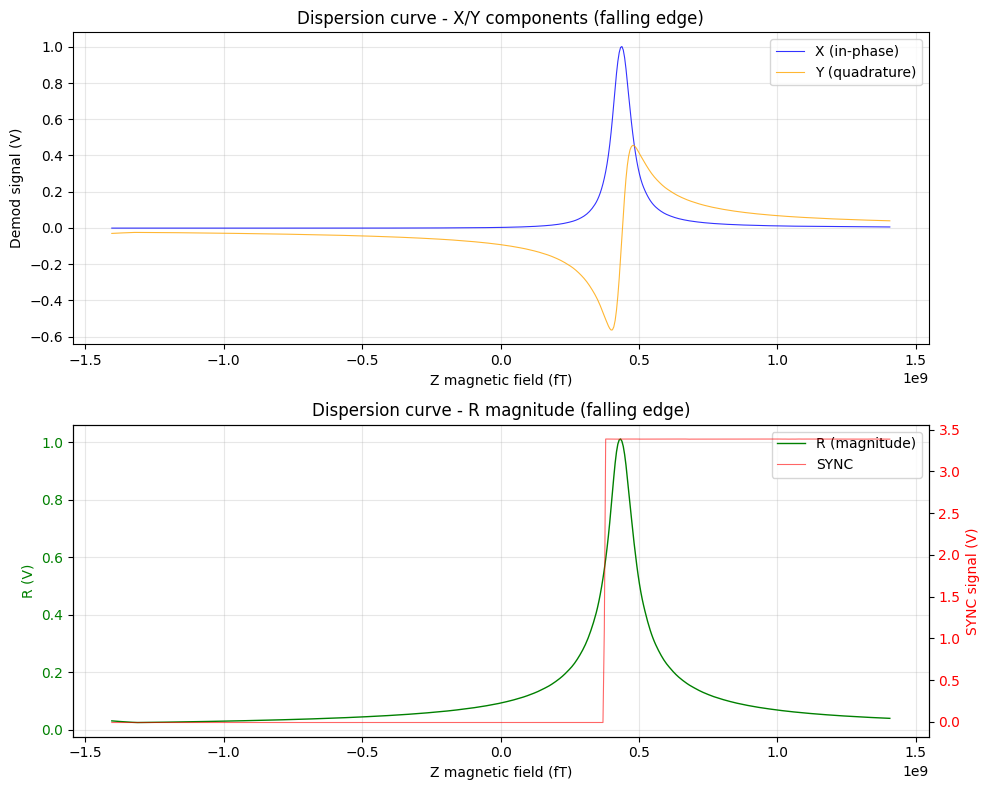

图表已保存: d:\Code\exp_agent\data\Static_Magnetic_Field_Sensitivity\0520_1652_sens\results\dispersion_curve.png


In [9]:
# ---- 绘制色散曲线 (下降段, 即 80% 区域) ----
# 对称性 20% → 上升段 20%, 下降段 80%
# 取下降段: 电压从 +0.5V 单调下降到 -0.5V, 无折叠
s = RAMP_SYMMETRY / 100.0
t_n = recorded_data["t_norm"]
# 下降段中间 80% (裁剪首尾各 10%, 避开转折区)
fall_start = s + (1.0 - s) * 0.1
fall_end = s + (1.0 - s) * 0.9
mask = (t_n >= fall_start) & (t_n < fall_end)

V = recorded_data["Z_voltage"][mask]  # 单调下降电压
B = V * Z_V_TO_FT                     # 电压 → 磁场

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for signal, label, color in zip(
    ["sample.x", "sample.y"],
    ["X (in-phase)", "Y (quadrature)"],
    ["blue", "orange"],
):
    if signal in recorded_data:
        data = recorded_data[signal][mask]
        axes[0].plot(B, data, "-", color=color, label=label, lw=0.8, alpha=0.8)
axes[0].set_xlabel("Z magnetic field (fT)")
axes[0].set_ylabel("Demod signal (V)")
axes[0].set_title("Dispersion curve - X/Y components (falling edge)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

ax1 = axes[1]
if "sample.r" in recorded_data:
    r_data = recorded_data["sample.r"][mask]
    ax1.plot(B, r_data, "-", color="green", label="R (magnitude)", lw=1)
ax1.set_xlabel("Z magnetic field (fT)")
ax1.set_ylabel("R (V)", color="green")
ax1.tick_params(axis="y", labelcolor="green")
ax1.grid(True, alpha=0.3)

if aux_key and aux_key in recorded_data:
    ax2 = ax1.twinx()
    aux_data = recorded_data[aux_key][mask]
    ax2.plot(B, aux_data, "-", color="red", alpha=0.6, lw=0.8, label="SYNC")
    ax2.set_ylabel("SYNC signal (V)", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

lines1, labels1 = ax1.get_legend_handles_labels()
if aux_key and aux_key in recorded_data:
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
else:
    ax1.legend(loc="upper right")
ax1.set_title("Dispersion curve - R magnitude (falling edge)")

plt.tight_layout()
fig.savefig(results_dir / "dispersion_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"图表已保存: {results_dir / 'dispersion_curve.png'}")

In [10]:
# ===== 灵敏度测量: 噪声采集 (多次平均提高频谱质量) =====
from scipy import signal as scipy_signal
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# 使用有效窗口内上升段找零交叉点 (无需排序, V 单调递增)
mask = recorded_data["effective_mask"] & recorded_data["rising_mask"]
V_rising = recorded_data["Z_voltage"][mask]
Y_rising = recorded_data["sample.y"][mask]

sign_changes = np.where(np.diff(np.sign(Y_rising)))[0]
if len(sign_changes) > 0:
    idx = sign_changes[len(sign_changes) // 2]
    v1, v2 = float(V_rising[idx]), float(V_rising[idx + 1])
    y1, y2 = float(Y_rising[idx]), float(Y_rising[idx + 1])
    V0 = v1 - y1 * (v2 - v1) / (y2 - y1)
    print(f"零交叉点: V0={V0:.4f}V, B0={V0*Z_V_TO_FT:.0f}fT")
else:
    V0 = 0.0; print("未找到零交叉点, 使用 V0=0")

print(f"TC={HF2_NOISE_TC*1e6:.0f}μs, Rate={HF2_NOISE_RATE} Sa/s")

# 配置解调器为高速率
noise_demod_cfg = DemodulatorConfig(
    demod_index=HF2_DEMOD_IDX, enable=True,
    rate=HF2_NOISE_RATE, input_channel=0,
    osc_select=0, harmonic=1,
    time_constant=HF2_NOISE_TC, order=HF2_DEMOD_ORDER,
    phase=calibrated_phase,
)
actual_rate_noise = demod.configure_demodulator(hfi, noise_demod_cfg)
time.sleep(0.3)

# 噪声测量时关闭 Z 磁场 (DC 0V + 输出关闭)
print("关闭 Z 磁场 (DC 0V, 输出 OFF)...")
dg_sweep.setup_dc(0.0, channel=1)
dg_sweep.set_output(False, channel=1)
time.sleep(0.5)

# ===== 多次采集，逐次保存到硬盘，避免内存累积 =====
# 每次采集时短暂关闭温控开关，采集后立即恢复，避免长时间温控中断导致温度漂移
fs_noise = float(actual_rate_noise)
noise_dir = raw_dir / "noise_raw"
noise_dir.mkdir(exist_ok=True)

# 记录初始温度作为基准
initial_temp = tec.get_temperature(channel=1)
print(f"初始温度: {initial_temp:.2f} °C")

for i in tqdm(range(NOISE_N_AVG), desc="采集噪声"):
    # 采集前关闭温控 (消除温控磁场对噪声测量的干扰)
    dg_temp.set_output(False, channel=2)
    noise_cfg = DAQConfig(device=MAPPING["lockin_r"]["device_id"],
        trigger_type=0, duration=NOISE_DURATION,
        grid_cols=int(fs_noise * NOISE_DURATION),
        grid_rows=1, grid_mode=2, signal_paths=["sample.y"])
    noise_results = daq.acquire_data(hfi, config=noise_cfg,
        demod_idx=HF2_DEMOD_IDX, actual_rate=fs_noise,
        timeout=NOISE_DURATION + 5.0)
    # 采集完立即恢复温控，等待温度稳定后再进行下一次
    dg_temp.set_output(True, channel=2)
    time.sleep(5)
    y = noise_results[0].values
    # 保存到硬盘后立即释放内存
    np.save(noise_dir / f"noise_{i:04d}.npy", y)
    del y, noise_results
    # 观察温度波动
    if i == 0 or i == NOISE_N_AVG - 1:
        t_now = tec.get_temperature(channel=1)
        print(f"  第 {i+1} 次采集后温度: {t_now:.2f} °C (偏差 {t_now - initial_temp:+.3f} °C)")

# ---- 读出保存的文件并累积 PSD ----
psd_sum = None
freq = None
nperseg = int(fs_noise * NOISE_DURATION)

for i in tqdm(range(NOISE_N_AVG), desc="计算 PSD"):
    y = np.load(noise_dir / f"noise_{i:04d}.npy")
    _, psd = scipy_signal.welch(y - np.mean(y), fs=fs_noise,
                                nperseg=nperseg, scaling="density")
    if psd_sum is None:
        freq = _
        psd_sum = psd.copy()
    else:
        psd_sum += psd
    del y, psd

psd_avg = psd_sum / NOISE_N_AVG

# 保存平均结果
np.savez(raw_dir / "noise_data.npz",
         psd_avg=psd_avg, freq=freq,
         fs=fs_noise, n_avg=NOISE_N_AVG)

print(f"噪声采集完成: {NOISE_N_AVG} 次, 分辨率 {freq[1]-freq[0]:.1f} Hz")
raw_file_size = NOISE_N_AVG * int(fs_noise * NOISE_DURATION) * 8 / 1024 / 1024
print(f"  原始数据已保存: {noise_dir}/ (共 {raw_file_size:.1f} MB)")

# ---- 恢复解调器至采集配置 ----
print("恢复解调器至采集配置...")
restore_demod_cfg = DemodulatorConfig(
    demod_index=HF2_DEMOD_IDX, enable=True,
    rate=HF2_DEMOD_RATE, input_channel=0,
    osc_select=0, harmonic=1,
    time_constant=HF2_DEMOD_TC, order=HF2_DEMOD_ORDER,
    phase=calibrated_phase,
)
demod.configure_demodulator(hfi, restore_demod_cfg)
time.sleep(0.2)
print("解调器已恢复 (rate=1000 Sa/s, TC=1ms)")

未找到零交叉点, 使用 V0=0
TC=1μs, Rate=50000 Sa/s
关闭 Z 磁场 (DC 0V, 输出 OFF)...
初始温度: 99.43 °C


采集噪声:   0%|          | 0/10 [00:00<?, ?it/s]

  第 1 次采集后温度: 99.06 °C (偏差 -0.377 °C)
  第 10 次采集后温度: 99.99 °C (偏差 +0.551 °C)


计算 PSD:   0%|          | 0/10 [00:00<?, ?it/s]

噪声采集完成: 10 次, 分辨率 1.0 Hz
  原始数据已保存: d:\Code\exp_agent\data\Static_Magnetic_Field_Sensitivity\0520_1652_sens\raw\noise_raw/ (共 4.4 MB)
恢复解调器至采集配置...
解调器已恢复 (rate=1000 Sa/s, TC=1ms)


Y 色散拟合: V0=0.1251V, dY/dB=2.582e-08 V/fT, B0=440044974fT
  线宽 HWHM: gamma=0.0111V = 38.96 nT = 38960714 fT
  线宽为: f = 272.7 Hz (µ_B/(4πħ) ≈ 7.00 Hz/nT ≈ 700 kHz/G)
加载平均 PSD: 10 次平均, 分辨率 1.0 Hz
最小 50 点中位数: 4.62e+02 fT/√Hz


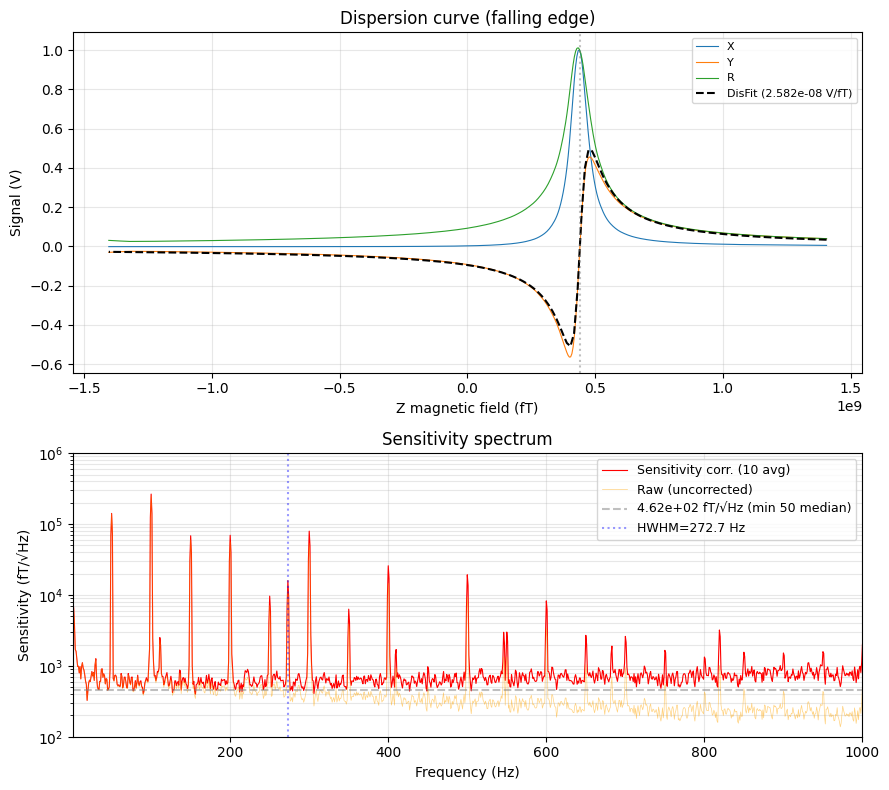

分析图已保存: d:\Code\exp_agent\data\Static_Magnetic_Field_Sensitivity\0520_1652_sens\results\full_analysiswithoutpump.png


In [11]:
# ===== 灵敏度分析: Y 色散拟合 + PSD + 合并绘图 =====
from scipy.optimize import curve_fit

def dispersive(x, A, gamma, x0, C):
    return A * (x - x0) / ((x - x0)**2 + gamma**2) + C

# Larmor 频率常数: f = µ_B·B / (4πħ), ≈ 7 Hz/nT ≈ 700 kHz/G
muB = 9.2740100783e-24                     # J/T, Bohr magneton
hbar = 1.054571817e-34                     # J·s
larmor_per_nT = muB / (4 * np.pi * hbar) * 1e-9  # Hz/nT

# ---- 1. Y 色散拟合 (下降段, 与绘图一致) ----
s = RAMP_SYMMETRY / 100.0
t_n = recorded_data["t_norm"]
fall_start = s + (1.0 - s) * 0.1
fall_end = s + (1.0 - s) * 0.9
fall_mask = (t_n >= fall_start) & (t_n < fall_end)

V_fit = recorded_data["Z_voltage"][fall_mask]     # 单调下降电压
Y_raw = recorded_data["sample.y"][fall_mask]

gamma_nT = 0.0  # 默认值, 拟合失败时回退
y_range = float(np.max(Y_raw) - np.min(Y_raw))
V_mid = float(np.mean(V_fit))
try:
    popt, _ = curve_fit(dispersive, V_fit, Y_raw,
                        p0=[y_range, 0.1, V_mid, 0], maxfev=5000)
    A, gamma, V0, C = popt
    slope_VV = abs(A) / (gamma**2) if gamma != 0 else 1.0
    slope = slope_VV / Z_V_TO_FT
    B0 = V0 * Z_V_TO_FT

    # 线宽换算: HWHM (V) → 磁场 (nT) → Larmor 频率 (Hz)
    gamma_nT = gamma * Z_V_TO_NT
    gamma_fT = gamma * Z_V_TO_FT
    f_larmor = gamma_nT * larmor_per_nT

    print(f"Y 色散拟合: V0={V0:.4f}V, dY/dB={slope:.3e} V/fT, B0={B0:.0f}fT")
    print(f"  线宽 HWHM: gamma={gamma:.4f}V = {gamma_nT:.2f} nT = {gamma_fT:.0f} fT")
    print(f"  线宽为: f = {f_larmor:.1f} Hz (µ_B/(4πħ) ≈ {larmor_per_nT:.2f} Hz/nT ≈ 700 kHz/G)")

    Vp = np.linspace(V_fit[0], V_fit[-1], 200)
    Yp = dispersive(Vp, *popt)
    Bp = Vp * Z_V_TO_FT
except Exception as e:
    print(f"拟合失败: {e}"); slope=1; V0=V_mid; B0=0
    Bp=np.array([]); Yp=np.array([])

# ---- 2. 灵敏度: 加载平均 PSD 计算灵敏度谱 ----
noise_data = np.load(raw_dir / "noise_data.npz")
freq = noise_data["freq"]
psd = noise_data["psd_avg"]                    # 平均 PSD
n_avg = int(noise_data["n_avg"])               # 采集次数
sens = np.sqrt(psd) / abs(slope)

# 响应曲线校正: 补偿有限线宽导致的高频滚降
# 原子自旋响应为洛伦兹型, 等效一阶低通, 校正因子 = sqrt(1 + (f/f_larmor)^2)
try:
    f_larmor  # 确保拟合已定义该变量
except NameError:
    f_larmor = 1000  # 拟合失败时使用默认值
correction = np.sqrt(1.0 + (freq / f_larmor)**2)
sens_corrected = sens * correction

print(f"加载平均 PSD: {n_avg} 次平均, 分辨率 {freq[1]-freq[0]:.1f} Hz")

# 灵敏度报告值: 取 sens_corrected 中最小的 100 个点的中位数
# 这种方法不受低频 1/f 噪声和高频校正放大区的影响，直接取谱上最优的统计值
N_TOP = min(50, len(sens_corrected))
sens_top100 = np.sort(sens_corrected)[:N_TOP]
sens_flat = float(np.median(sens_top100))

analysis = {"B0_fT": B0, "slope_V_per_fT": slope, "sens_flat_fT_per_sqrt_Hz": sens_flat,
            "n_avg": n_avg, "freq_resolution_Hz": float(freq[1]-freq[0]),
            "f_linewidth_Hz": f_larmor, "n_top": N_TOP}
with open(results_dir / "analysis.json", "w") as f:
    json.dump(analysis, f, indent=2)
print(f"最小 {N_TOP} 点中位数: {sens_flat:.2e} fT/√Hz")

# ---- 3. 合并绘图 (下降段, 电压单调, 按时序画图) ----
V_all = recorded_data["Z_voltage"][fall_mask]
B_all = V_all * Z_V_TO_FT

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), height_ratios=[1.2, 1])

ax1.plot(B_all, recorded_data["sample.x"][fall_mask], "-", lw=0.8, label="X")
ax1.plot(B_all, recorded_data["sample.y"][fall_mask], "-", lw=0.8, label="Y")
ax1.plot(B_all, recorded_data["sample.r"][fall_mask], "-", lw=0.8, label="R")
if len(Yp) > 0:
    ax1.plot(Bp, Yp, "k--", lw=1.5, label=f"DisFit ({slope:.3e} V/fT)")
ax1.axvline(B0, color="gray", ls=":", alpha=0.5)
ax1.set_xlabel("Z magnetic field (fT)"); ax1.set_ylabel("Signal (V)")
ax1.set_title("Dispersion curve (falling edge)"); ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.plot(freq, sens_corrected, "r-", lw=0.8, label=f"Sensitivity corr. ({n_avg} avg)")
ax2.plot(freq, sens, "orange", lw=0.5, alpha=0.5, label="Raw (uncorrected)")
if sens_flat > 0:
    ax2.axhline(sens_flat, color="gray", ls="--", alpha=0.5,
                label=f"{sens_flat:.2e} fT/√Hz (min {N_TOP} median)")
ax2.axvline(f_larmor, color="blue", ls=":", alpha=0.4, label=f"HWHM={f_larmor:.1f} Hz")
ax2.legend(fontsize=9)
ax2.set_xlabel("Frequency (Hz)"); ax2.set_ylabel("Sensitivity (fT/√Hz)")
ax2.set_title("Sensitivity spectrum"); ax2.grid(True, alpha=0.3, which="both")
ax2.set_xlim(1, 1000)
ax2.set_ylim(1e2, 1e6)
ax2.set_yscale("log")

plt.tight_layout()
fig.savefig(results_dir / "full_analysiswithoutpump.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"分析图已保存: {results_dir / 'full_analysiswithoutpump.png'}")

## 灵敏度分析

$$\delta B(f) = \frac{\sqrt{\text{PSD}_Y(f)}}{|dY/dB|} \quad [\text{fT}/\sqrt{\text{Hz}}]$$

- $dY/dB$: 色散曲线零交叉点斜率 (V/fT)
- $\text{PSD}_Y$: Y 信号功率谱密度 (V²/Hz)

### 响应曲线校正

原子自旋响应为洛伦兹型，等效一阶低通滤波器：

$$\delta B_{\text{corr}}(f) = \delta B(f) \times \sqrt{1 + (f/f_{\text{HWHM}})^2}$$

在 $\text{HWHM}$ 以下校正因子接近 1，以上则放大灵敏度。

### 灵敏度报告值

对校正后灵敏度谱 `sens_corrected` 排序，取最小的 100 个点的中位数。这种方法直接取谱上最优统计值，不受低频 1/f 噪声和高频校正放大区的影响。

### 流程

1. **采集噪声**: 切换到 TC=10μs, 关闭 Z 磁场, 采 1s Y 噪声, 重复 `NOISE_N_AVG` 次
2. **PSD 平均**: 对各次 Welch 法求 PSD 后等权平均, 降低频谱涨落 ($\propto 1/\sqrt{N}$)
3. **拟合**: 对色散曲线 Y 做色散拟合, 得 $dY/dB$
4. **灵敏度**: $\delta B = \sqrt{\text{PSD}_{\text{avg}}} / |dY/dB|$
5. **响应校正**: 补偿有限线宽的高频滚降

### 参数

- `NOISE_N_AVG`: 噪声采集次数 (在 Cell 2 中设置, 默认 10)
- `Z_V_TO_NT`: 磁场校准系数 (在 Cell 2 中设置)

In [12]:
# ---- 断开所有设备（保持输出状态不变） ----

print("正在断开设备...")
print("（所有设备输出状态保持当前设置不变）")

# 仅断开连接，不改变任何输出状态
for name, dev in devices.items():
    if hasattr(dev, "disconnect"):
        try:
            dev.disconnect()
            print(f"  {name} 已断开")
        except Exception as e:
            print(f"  {name} 断开失败: {e}")

print("所有设备已断开")

正在断开设备...
（所有设备输出状态保持当前设置不变）
  gs200 已断开
  dg_sweep 已断开
  dg_laser 已断开
  dg_comp 已断开
  dg_mod 已断开
  dg_temp 已断开
  tec 已断开
  hf2 已断开
所有设备已断开
